# skyweaver tutorial

This notebook walks through a first end-to-end `skyweaver` workflow:

- define an artificial satellite orbit
- choose one or more observatories
- build a time grid
- compute ground and sky tracks
- visualise the results in geographic, polar, and HEALPix views
- compare how the same orbit is seen from different sites

In [1]:
from datetime import datetime, timezone

import cmasher as cmr
import matplotlib.pyplot as plt
import numpy as np

from skyweaver import Observatory, OrbitSpec, TimeGrid, ground_track, sky_track
from skyweaver.viz import plot_ground_track, plot_sky_track, plot_sky_track_healpix

pride = cmr.pride.copy()
pride.set_under("white")

## 1. Define a first test orbit

We start with a simple circular low-Earth orbit:

- altitude: 550 km
- inclination: 70°
- RAAN: 30°
- phase: 120°

This is not meant to represent a specific real satellite. It is just a useful artificial test case for exploring the package.

In [2]:
orbit = OrbitSpec.circular(
    name="test_550km_i70",
    epoch=datetime(2026, 1, 1, tzinfo=timezone.utc),
    altitude_km=550.0,
    inclination_deg=70.0,
    raan_deg=30.0,
    phase_deg=120.0,
)

In [3]:
print(orbit.summary())
print(f"Semi-major axis [km]: {orbit.semi_major_axis_km:.3f}")
print(f"Period [min]: {orbit.period_min:.3f}")
print(f"Mean motion [rev/day]: {orbit.mean_motion_rev_day:.3f}")

OrbitSpec(name='test_550km_i70', altitude_km=550.0, inclination_deg=70.000, raan_deg=30.000, mean_anomaly_deg=120.000, eccentricity=0.000000, period_min=95.65)
Semi-major axis [km]: 6928.137
Period [min]: 95.650
Mean motion [rev/day]: 15.055


## 2. Choose an observatory

`skyweaver` includes a small registry of built-in observatories. We can inspect the available site names and then select one for our first sky-track calculation.

In [4]:
Observatory.names()

['ALBATROS',
 'CHORD',
 'GMRT',
 'HERA',
 'HIRAX',
 'LOFAR',
 'MWA',
 'NENUFAR',
 'OVRO_LWA',
 'SKA_LOW']

In [5]:
site = Observatory.get("MWA")
site

Observatory(name='MWA', latitude_deg=-26.703319, longitude_deg=116.670815, elevation_m=377.83)

## 3. Build a time grid

We now define the interval over which the orbit will be sampled. For demonstration purposes, one month at 30-second cadence gives enough coverage to show repeated passes and meaningful HEALPix accumulation, while still being manageable for an example notebook.

In [6]:
grid = TimeGrid(
    start=datetime(2026, 1, 1, 0, 0, 0, tzinfo=timezone.utc),
    stop=datetime(2026, 2, 1, 0, 0, 0, tzinfo=timezone.utc),
    cadence_s=20.0,
)

print(grid.summary())

TimeGrid(start=2026-01-01T00:00:00+00:00, stop=2026-02-01T00:00:00+00:00, cadence_s=20.000, n_times=133921)


## 4. Compute the tracks

The same orbit can be viewed in two complementary ways:

- a **ground track**, showing the sub-satellite point on Earth
- a **sky track**, showing the satellite in altitude/azimuth as seen from a chosen observatory

In [7]:
gt = ground_track(orbit, grid)
st = sky_track(orbit, site, grid)

print(gt.summary())
print(st.summary())

GroundTrack(orbit='test_550km_i70', n_times=133921)
SkyTrack(orbit='test_550km_i70', observatory='MWA', n_times=133921)


In [8]:
gt.latitude_deg[:4], gt.longitude_deg[:4]

(array([54.58639837, 53.56587603, 52.53294884, 51.48860567]),
 array([78.73511572, 79.89017824, 80.98673196, 82.02894665]))

In [9]:
st.altitude_deg[:4], st.azimuth_deg[:4], st.range_km[:4]

(array([-41.32266354, -40.65443746, -39.98488969, -39.31396591]),
 array([338.96769106, 338.984008  , 338.99740145, 339.00790919]),
 array([9187.07632267, 9083.81918088, 8979.52265482, 8874.19925557]))

## 5. Plot the ground track

Here we show the orbit projected onto a simple world map and overlay several observatory locations for context.

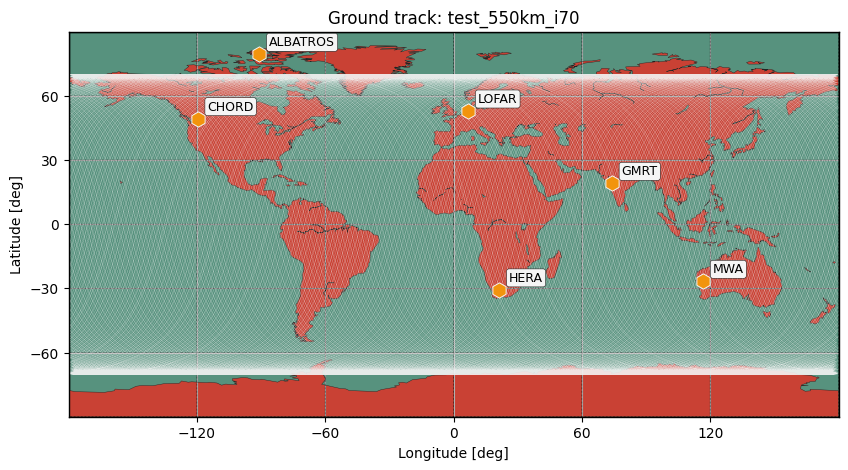

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_ground_track(
    gt,
    ax=ax,
    observatories=[
        Observatory.get("MWA"),
        Observatory.get("LOFAR"),
        Observatory.get("HERA"),
        Observatory.get("ALBATROS"),
        Observatory.get("CHORD"),
        Observatory.get("GMRT"),
    ],
)
plt.show()

## 6. Plot the sky track at MWA

This is the same orbit, but now shown in local altitude/azimuth as seen from the MWA. Each rise-to-set pass is split and plotted separately, and the colormap is used to assign a distinct colour to each pass.

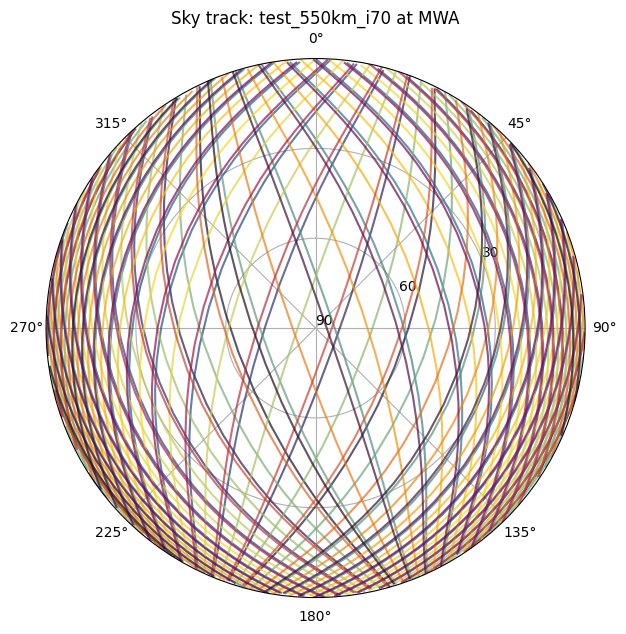

In [11]:
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(7, 7))
plot_sky_track(st, ax=ax, alpha=0.7, cmap=pride)
plt.show()

## 7. Accumulate the sky coverage into a HEALPix map

A HEALPix map is useful when you care less about the detailed sequence of individual passes and more about where on the sky the orbit repeatedly samples.

With `unique_per_pass=True`, each pixel is counted at most once per pass, which avoids overweighting densely sampled points within a single pass.

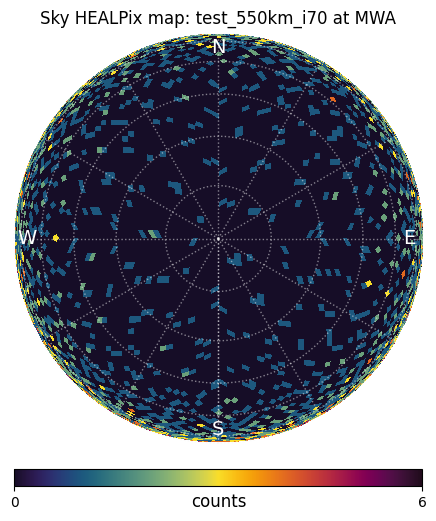

In [12]:
healpix_map = plot_sky_track_healpix(
    st,
    nside=32,
    unique_per_pass=True,
    cmap=pride,
    bgcolor="white",
)
plt.show()

## 8. Basic visibility diagnostics

A quick way to summarise how useful a given orbit is for a site is to look at how often it is above the horizon and how high it gets.

In [13]:
visible = st.visible
print(f"Number of visible samples: {visible.sum()} / {st.n_times}")
print(f"Maximum altitude [deg]: {np.nanmax(st.altitude_deg):.3f}")
print(f"Number of distinct passes: {len(st.passes())}")

Number of visible samples: 4319 / 133921
Maximum altitude [deg]: 83.641
Number of distinct passes: 145


## 9. Altitude as a function of time

The polar sky plot is intuitive geometrically, but an altitude-versus-time plot is often the quickest way to identify rise, culmination, and set behaviour.

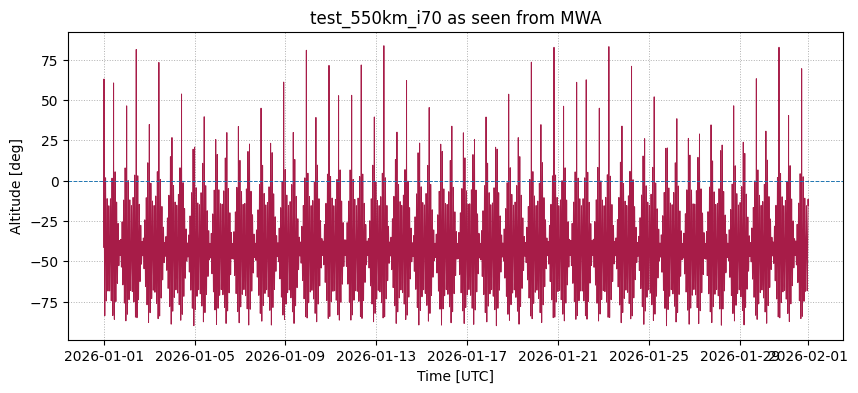

In [14]:
times = grid.datetimes()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, st.altitude_deg, lw=0.7, color=cmr.pride(0.8))
ax.axhline(0.0, ls="--", lw=0.7)
ax.set_ylabel("Altitude [deg]")
ax.set_xlabel("Time [UTC]")
ax.set_title(f"{orbit.name} as seen from {site.name}")
ax.grid(ls=":", lw="0.7")
plt.show()

## 10. Compare other observatories

A nice feature of this workflow is that you can reuse the same orbit and time grid, changing only the observatory. This makes it easy to compare how the same satellite shell would illuminate different instruments.

In [15]:
def summarise_site(site_name: str) -> None:
    site_i = Observatory.get(site_name)
    st_i = sky_track(orbit, site_i, grid)

    print(site_i.name)
    print(f"  Visible samples: {st_i.visible.sum()} / {st_i.n_times}")
    print(f"  Number of passes: {len(st_i.passes())}")
    print(f"  Max altitude [deg]: {np.nanmax(st_i.altitude_deg):.3f}")

    fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(7, 7))
    plot_sky_track(st_i, ax=ax, cmap=pride, alpha=0.7)
    plt.show()

    plot_sky_track_healpix(
        st_i,
        nside=32,
        unique_per_pass=True,
        cmap=pride,
        bgcolor="white",
    )
    plt.show()

LOFAR
  Visible samples: 8145 / 133921
  Number of passes: 261
  Max altitude [deg]: 89.422


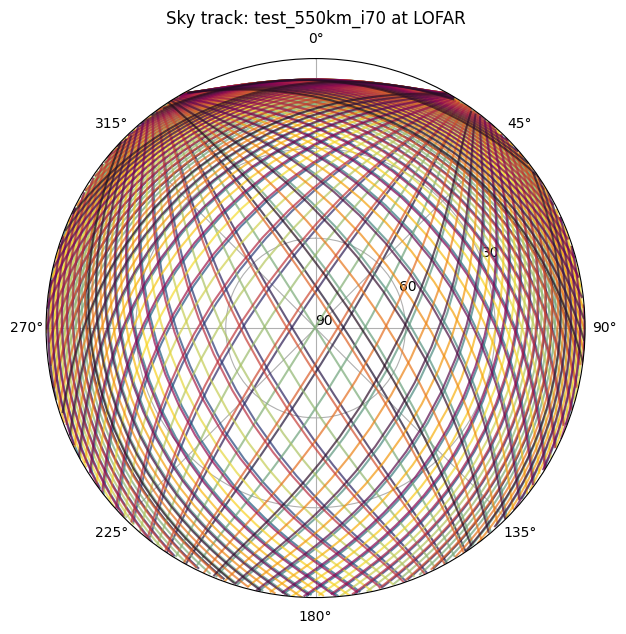

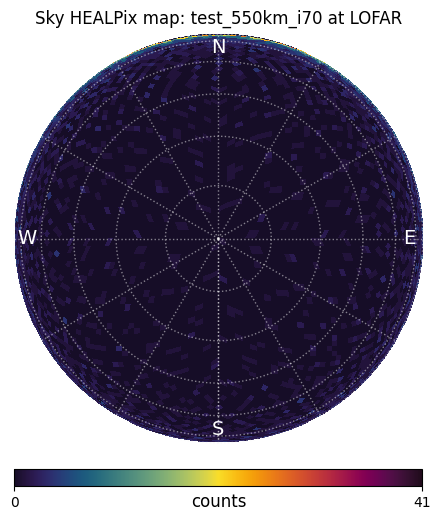

In [16]:
summarise_site("LOFAR")

HERA
  Visible samples: 4563 / 133921
  Number of passes: 154
  Max altitude [deg]: 84.383


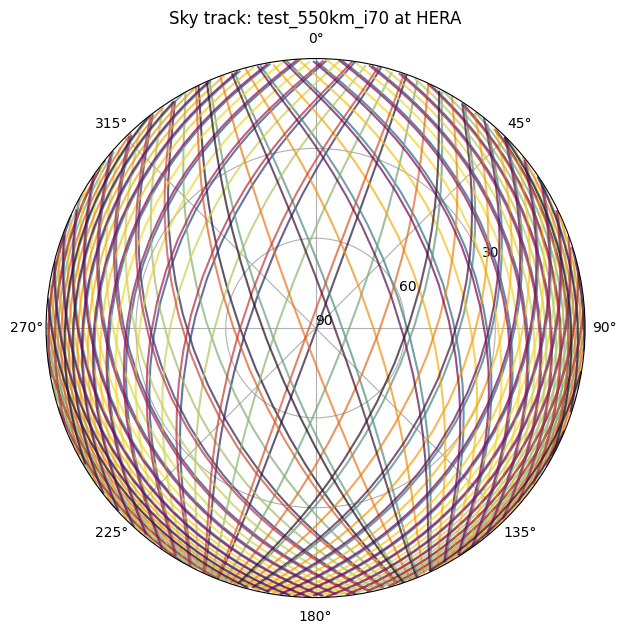

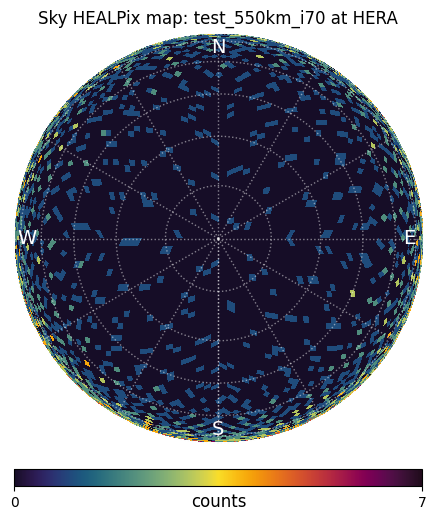

In [17]:
summarise_site("HERA")